# 4. Couple two models

**You need: one GPU.**

**Runtime: about 80 seconds** (measured: 69 s and 89 s).

Two independently trained models, run together as one forecast system, with no
retraining and no shared encoder. This notebook shows how that is possible,
proves the plumbing is not doing anything behind your back, and then runs the
experiment the challenge actually asks about.

Read [`docs/05_coupling.md`](../docs/05_coupling.md) alongside.

In [ ]:
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra.utils import instantiate
from torch.utils.data import DataLoader, Subset

# Only the noisy third-party deprecations, NOT everything: a bare
# `filterwarnings("ignore")` also silences all 13 of this kit's own
# diagnostics -- including the figure- and animation-skip warnings, which is
# how a run comes back with 4 figures where the last one had 10 and nobody
# notices.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
assert torch.cuda.is_available(), "This notebook needs a GPU."
print(torch.cuda.get_device_name(0))

## 1. A "component" is two lists

Which variables a model **predicts**, and which it only **reads**. That is the
whole abstraction, and it lives in `variables.py`.

In [ ]:
from oceanarches.dataloaders import variables as V  # noqa: E402

for name, spec in V.COMPONENTS.items():
    print(f"{name:16s} predicts {len(spec.prognostic):2d}: {spec.prognostic}")
    print(f"{'':16s} reads    {len(spec.forcing):2d}: {spec.forcing}")
    print(f"{'':16s} channels in/out  surface {spec.n_surface_in}/{spec.n_surface_out}"
          f"   level {spec.n_level_in}/{spec.n_level_out}")
    print()

The dataloader config picks the component, and the module, the embedder's
channel counts, the loss and the metrics all read `${dataloader.component}` --
so `dataloader=glorys_seaice` rewires all of them at once and they cannot
disagree.

Note the input order: **own variables first, then forcing**. That is what makes
"the model's output is the leading `n_out` channels of its input" true, and the
whole component scheme rests on it.

## 2. The router: index bookkeeping and nothing else

A coupled system holds **one** shared state in **one** channel order -- the
*union* of its parts, which for ocean + sea ice is exactly the `full`
component.

In [ ]:
from oceanarches.lightning_modules.coupled import StateRouter, union_component  # noqa: E402

layout = union_component([V.COMPONENTS["ocean"], V.COMPONENTS["seaice"]])
print("union of ocean + seaice :", layout.name)
print("  predicts:", layout.prognostic)
print("  reads   :", layout.forcing, "(nothing: between them they own the whole state)")
print("  surface:", layout.input_surface)
print("  level  :", layout.input_level)
print("  identical to COMPONENTS['full']:",
      layout.input_surface == V.COMPONENTS["full"].input_surface
      and layout.input_level == V.COMPONENTS["full"].input_level)

router = StateRouter.for_layout(layout)
print("\nrouter:", router)

In [ ]:
from tensordict.tensordict import TensorDict  # noqa: E402

# A fake shared state whose channel c is filled with the value c, so you can read
# the permutation straight off the numbers.
shared = TensorDict(
    surface=torch.arange(7, dtype=torch.float32).reshape(1, 7, 1, 1, 1).expand(1, 7, 1, 4, 5).clone(),
    level=torch.arange(4, dtype=torch.float32).reshape(1, 4, 1, 1, 1).expand(1, 4, 3, 4, 5).clone(),
    batch_size=[1],
)
print("shared surface channels :", shared["surface"][0, :, 0, 0, 0].tolist(),
      "=", layout.input_surface)

ice_in = router.gather(shared, V.COMPONENTS["seaice"])
print("gathered for `seaice`   :", ice_in["surface"][0, :, 0, 0, 0].tolist(),
      "=", V.COMPONENTS["seaice"].input_surface)

# the ice model predicts 4 surface channels; pretend it returned -1 in all of them
ice_out = TensorDict(
    surface=torch.full((1, 4, 1, 4, 5), -1.0), batch_size=[1]
)
after = router.scatter(shared, V.COMPONENTS["seaice"], ice_out)
print("after scatter           :", after["surface"][0, :, 0, 0, 0].tolist())
print("                          ^ only the sea-ice channels moved; the rest passed through")

`gather` selects a component's inputs **in the order its own embedder was wired
for**; `scatter` writes back only its prognostic channels and carries
everything else by reference.

This works at all because `forward_multistep` is a **grid-space** rollout:
every step produces a full physical state on the 180x360 grid and nothing is
carried between steps in a latent space. A prediction is an ordinary field, and
an ordinary field can be written into a shared state.

## 3. The control: coupling one model to nothing must change nothing

Before believing any coupled number, check that a "coupled system" built from a
single `full` component reproduces that component alone.

In [ ]:
from geoarches.lightning_modules.base_module import load_module  # noqa: E402

from oceanarches.lightning_modules.coupled import CoupledForecastModule  # noqa: E402

alone, cfg = load_module("modelstore/task6_tiny", device="cuda")
alone = alone.eval()
# `device=` only says where components loaded from a path are put; the coupled
# module's own buffers (masks, statistics) follow the usual `.to()`.
coupled_one = CoupledForecastModule(components={"full": alone}).to("cuda").eval()

torch.manual_seed(0)
state = TensorDict(
    surface=torch.randn(1, 7, 1, 180, 360, device="cuda"),
    level=torch.randn(1, 4, 13, 180, 360, device="cuda"),
    batch_size=[1],
)
batch = dict(state=state, prev_state=state.clone(),
             timestamp=torch.tensor([1_600_000_000], device="cuda"),
             lead_time_hours=torch.tensor([24], device="cuda"))

with torch.no_grad():
    a = alone.forward_multistep(batch, iters=3)
    b = coupled_one.forward_multistep(batch, iters=3)

for group in ("surface", "level"):
    diff = float((a[group] - b[group]).abs().max())
    print(f"{group:8s} max |difference| = {diff:.3e}   bit-identical: {bool((a[group] == b[group]).all())}")

`0.000e+00`. And it is not vacuous: the router really does run -- `gather`
fires twice per step and `scatter` once -- it is simply the identity
permutation for a component that owns the whole state.

The statistics, wet masks, loss coefficients and denormalisation are
**borrowed** from the single-model module rather than reassembled from the
parts, which is what makes a coupled loss comparable with an uncoupled one.

## 4. The real thing: an ocean model and a sea-ice model

`ocean_tiny` and `seaice_tiny` ship with the kit. They were trained for 2000
steps each to prove the plumbing, so **do not read any skill conclusion into
their scores.**

In [ ]:
from types import SimpleNamespace  # noqa: E402

from oceanarches.evaluation import rollout  # noqa: E402
from oceanarches.evaluation import run_eval as RE  # noqa: E402
from oceanarches.evaluation.baselines import (  # noqa: E402
    ClimatologyForecast,
    ModelForecast,
    PersistenceForecast,
)

LEAD, N_INITS = 10, 8


def coupled_config(components, mode="sequential", forcing="persistence", name="notebook"):
    """Compose configs/module/coupled.yaml exactly as `make couple` does.

    This is why the arms below are comparable: the shared-state layout, the
    metric set and the dataloader all come from the shipped config, chosen from
    the *union* of the components rather than assumed.
    """
    args = SimpleNamespace(mode=mode, unpredicted_forcing=forcing,
                           lead_days=LEAD, exp=name, order=list(components))
    return RE.compose_coupled_config(components, list(components), args)


def score(components, mode="sequential", forcing="persistence", label="coupled"):
    """Roll out and score, through the same pipeline `make eval` uses."""
    # hydra reads `++name=...` off a command line, so the run name must not
    # contain a comma or a space; the label is only for the legend.
    name = label.replace(", ", "_").replace(" ", "_")
    cfg = coupled_config(components, mode=mode, forcing=forcing, name=name)
    module = instantiate(cfg.module.module, device="cuda").to("cuda").eval()

    test_args = dict(cfg.dataloader.get("test_args", {}))
    test_args["multistep"] = LEAD
    dataset = instantiate(cfg.dataloader.dataset, **test_args)
    inits = rollout.choose_initialisations(len(dataset), n_inits=N_INITS, selection="spread")
    loader = DataLoader(Subset(dataset, inits), batch_size=4, shuffle=False,
                        collate_fn=rollout.collate_fn)

    forecasters = [ModelForecast(module, label=label),
                   PersistenceForecast(module),
                   ClimatologyForecast(module).to("cuda")]
    metrics = {f.key: rollout.build_metrics(cfg, LEAD, "cuda") for f in forecasters}
    losses = {}
    with torch.no_grad():
        for batch in loader:
            rollout.score_batch(module, forecasters,
                                {k: v.to("cuda") for k, v in batch.items()},
                                LEAD, metrics, losses)
    flat = {}
    for key, group in metrics.items():
        entry = {}
        for m in group.values():
            entry.update({k: float(v) for k, v in m.compute().items()})
        flat[key] = entry
    return {"module": module, "inits": inits,
            "loss": {k: v / len(inits) for k, v in losses.items()}, "metrics": flat}


pair = {"ocean": "ocean_tiny", "seaice": "seaice_tiny"}
probe = instantiate(coupled_config(pair).module.module, device="cuda")
print("coupled component  :", probe.component.name)
print("order              :", probe.order, " mode:", probe.mode)
print("unpredicted forcing:", probe.unpredicted_forcing)
del probe

started = time.time()
sequential = score(pair, mode="sequential", label="coupled, sequential")
parallel = score(pair, mode="parallel", label="coupled, parallel")
print(f"\n{time.time() - started:.0f} s for two coupled rollouts of "
      f"{N_INITS} initialisations x {LEAD} days")

## 5. `sequential` against `parallel`

The only difference is whether the sea-ice model sees the ocean this step has
already produced, or the ocean at time *t*.

In [ ]:
print(f"loss  sequential {sequential['loss']['model']:.6f}"
      f"   parallel {parallel['loss']['model']:.6f}")
print(f"      difference {abs(sequential['loss']['model'] - parallel['loss']['model']):.3e}")
print()
print("the baselines, which must NOT move (the control):")
for key in ("persistence", "climatology"):
    print(f"  {key:12s} {sequential['loss'][key]:.9f}   {parallel['loss'][key]:.9f}"
          f"   difference {abs(sequential['loss'][key] - parallel['loss'][key]):.3e}")

In [ ]:
labels = [k for k in sequential["metrics"]["model"] if k.startswith("rmse_")]
differ = [k for k in labels
          if sequential["metrics"]["model"][k] != parallel["metrics"]["model"][k]]
print(f"{len(differ)} of {len(labels)} rmse labels differ between the two modes")

print(f"\n{'label':<24}{'sequential':>14}{'parallel':>14}")
for k in ("rmse_zos_24h", "rmse_zos_48h", "rmse_siconc_24h", "rmse_siconc_240h",
          "rmse_sithick_240h"):
    if k in sequential["metrics"]["model"]:
        print(f"{k:<24}{sequential['metrics']['model'][k]:14.8f}"
              f"{parallel['metrics']['model'][k]:14.8f}")

Three things to read off that:

1. **The modes genuinely differ** -- but by a fraction of a percent. At a
   24-hour coupling step and this model's skill, whether the ice sees today's
   ocean or yesterday's is a second-order effect. Halve the step and it should
   grow: that is a real experiment for a team to run.
2. **`zos` at day 1 is bit-identical** and only diverges from day 2. That is
   the ordering doing exactly what it says -- the ocean runs first, so at the
   first step it reads the same state either way, and the difference reaches it
   only through the ice fields it reads on the *next* step.
3. **The baselines are identical.** The difference is in the forecast, not in
   the scoring. Always check that.

## 6. How much does the ice get from the ocean?

Three arms with the **same sea-ice weights**. Only what they are told about the
ocean changes, so any difference is information rather than optimisation luck.

| arm | the ocean it sees |
|---|---|
| true ocean | read from the dataset at every valid time (perfect forcing) |
| frozen ocean | held at the initial state (free-running) |
| predicted ocean | produced by `ocean_tiny`, every step |

And a fourth, `seaice_isolated`, which is **different weights**: a model that
never had an ocean channel at all.

In [ ]:
started = time.time()
arms = {
    "true ocean": score({"seaice": "seaice_tiny"}, forcing="ground_truth", label="true ocean"),
    "frozen ocean": score({"seaice": "seaice_tiny"}, label="frozen ocean"),
    "predicted ocean": sequential,
    "no ocean at all": score({"seaice_isolated": "seaice_isolated_tiny"}, label="no ocean"),
}
print(f"{time.time() - started:.0f} s for the remaining arms")

In [ ]:
rows = ["rmse_siconc_240h", "rmse_sithick_240h", "iiee_seaiceNH_240h", "iiee_seaiceSH_240h"]
print(f"{'':<18}" + "".join(f"{r.replace('_240h',''):>20}" for r in rows))
for name, arm in arms.items():
    print(f"{name:<18}" + "".join(
        f"{arm['metrics']['model'].get(r, float('nan')):20.6f}" for r in rows))
print(f"{'persistence':<18}" + "".join(
    f"{arms['frozen ocean']['metrics']['persistence'].get(r, float('nan')):20.6f}" for r in rows))

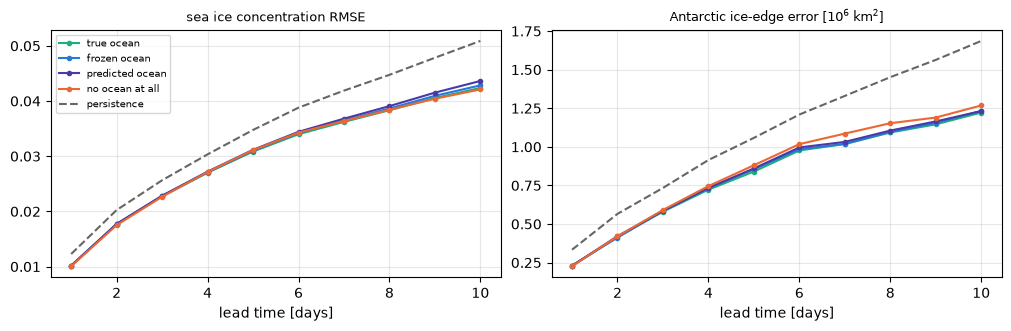

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)
colours = ["#1baf7a", "#2a78d6", "#4a3aa7", "#eb6834"]
for ax, (metric, title) in zip(axes, [("rmse_siconc", "sea ice concentration RMSE"),
                                      ("iiee_seaiceSH", "Antarctic ice-edge error [10$^6$ km$^2$]")]):
    for (name, arm), colour in zip(arms.items(), colours):
        y = [arm["metrics"]["model"][f"{metric}_{24 * (d + 1)}h"] for d in range(LEAD)]
        ax.plot(np.arange(1, LEAD + 1), y, "o-", ms=3, color=colour, label=name)
    y = [arms["frozen ocean"]["metrics"]["persistence"][f"{metric}_{24 * (d + 1)}h"]
         for d in range(LEAD)]
    ax.plot(np.arange(1, LEAD + 1), y, "--", color="#666666", label="persistence")
    ax.set_xlabel("lead time [days]"); ax.set_title(title, fontsize=9); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7)
plt.show()

## What that says, and what it does not

**The ordering `true ocean` < `frozen ocean` < `predicted ocean` is the
coupling result** -- it holds on `siconc`, `sithick` and Arctic ice-edge error
in the table above -- and it is not the comfortable one:

> The same sea-ice weights do **best** when handed the true ocean, **worse**
> when the ocean is frozen at its initial state, and **worst** when the ocean
> comes from a model.

**A coupled system inherits its weakest component's error.** Here that is
stark: `ocean_tiny` at 2000 steps loses to persistence, so coupling the ice to
it is worse than telling the ice that nothing changed. **Check each component
against persistence before you believe a coupled score.**

**`no ocean at all` is not a clean ablation.** It is different weights: 4 input
channels instead of 11, a latent vertical of 1 instead of 8, the same 2000
steps. At this budget the smaller problem is simply easier to optimise, which
is why it *wins* on `siconc`. Where the comparison is least confounded -- the
Southern Hemisphere ice edge, which the Southern Ocean drives -- it is the
worst arm. That is the honest reading: *ocean information helps the ice edge,
most visibly in the Antarctic; on the interior pack at 10 days it is within the
noise of how these two models were trained.*

Note also that eight initialisations is a small sample. The shipped
[docs/05](../docs/05_coupling.md#55-what-the-measurements-actually-said) runs
the same arms at sixteen; the ordering is the same and the margins move a
little, which tells you how much of this is signal.

To make it clean: train the blind model until its **training** loss matches the
other's, or keep the architecture identical and feed the ocean channels as pure
noise, so the only difference is the information.

## 7. The same thing from the command line

Everything above is one target and a handful of flags. This is what to copy:

```bash
make couple OCEAN=ocean_tiny SEAICE=seaice_tiny            # + figures, animations, report
make couple OCEAN=ocean_tiny SEAICE=seaice_tiny MODE=parallel

P=".venv/bin/python -m oceanarches.evaluation.run_eval"
COMMON="--lead-days 10 --n-inits 16 --init-selection spread"
$P --coupled --components seaice=seaice_tiny --unpredicted-forcing ground_truth $COMMON
$P --coupled --components seaice=seaice_tiny                                    $COMMON
$P --coupled --components seaice_isolated=seaice_isolated_tiny                  $COMMON

$P --coupled --components ocean=ocean_tiny seaice=seaice_tiny --lead-days 10 \
   --compare-with "ice, true ocean=coupled_seaice_sequential_ground_truth" \
                  "ice, no ocean=coupled_seaice_isolated_sequential" \
                  "ice, frozen ocean=coupled_seaice_sequential"
```

`--lead-days`, `--n-inits` and `--init-selection` **must match across every
arm**, or the numbers are not comparable. Every run records all three in its
manifest, so a mismatch is visible rather than silent.

## Next

* [`docs/07_challenge_ideas.md`](../docs/07_challenge_ideas.md) -- experiments
  1a to 1d are exactly this, done properly.